Initializing Backtest Engine...
Fetching historical data to calculate daily returns...


[*********************100%***********************]  3 of 3 completed


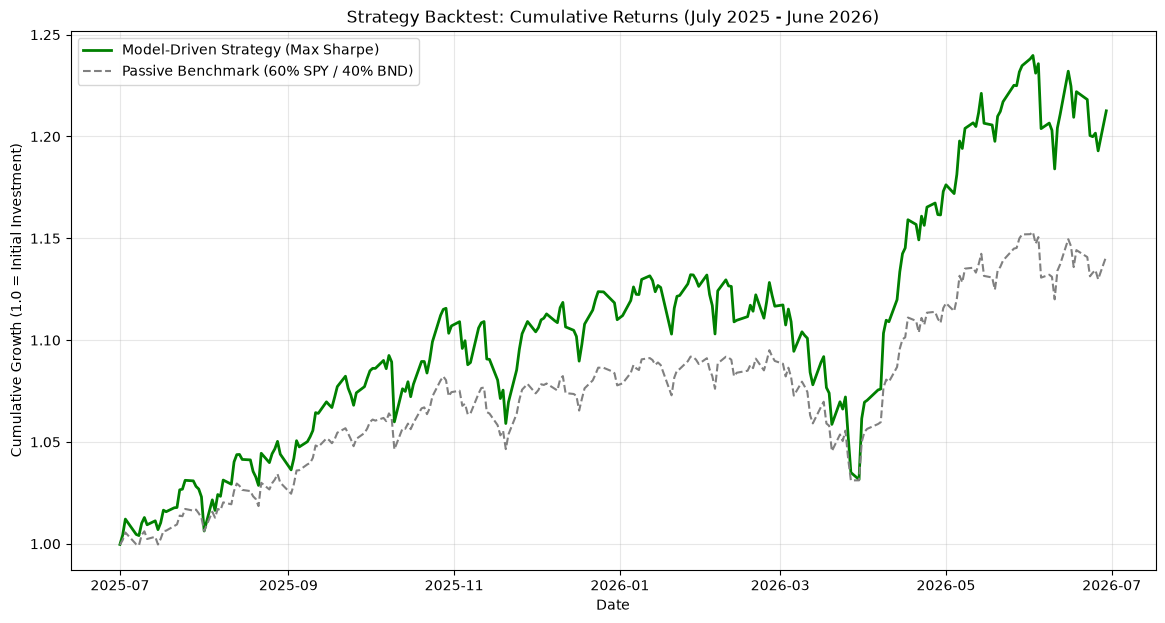


=== BACKTESTING PERFORMANCE METRICS (1-Year) ===


,Model Strategy,Benchmark (60/40)
Metric,,
Total Return,21.26%,14.13%
Annualized Return,21.45%,14.25%
Sharpe Ratio,1.37,1.24
Maximum Drawdown,-8.88%,-5.84%


In [1]:
#  Strategy Backtesting & Performance Evaluation
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display
import yfinance as yf
import requests

print("Initializing Backtest Engine...")

print("Fetching historical data to calculate daily returns...")
session = requests.Session()
session.headers['User-agent'] = 'Mozilla/5.0'
tickers = ['TSLA', 'SPY', 'BND']
data = yf.download(tickers, start='2015-01-01', end='2026-06-30', session=session)

# Clean up index and extract Close prices
data.index = pd.to_datetime(data.index).tz_localize(None)
if isinstance(data.columns, pd.MultiIndex):
    close_prices = data['Close'].copy()
else:
    close_prices = data.copy()


daily_returns = close_prices.pct_change().dropna()

# Define Backtesting Period (Last 1 year: July 2025 - June 2026)
backtest_start = '2025-07-01'
bt_returns = daily_returns[backtest_start:].copy()

# Define Portfolios
# Strategy: The optimal weights found by our Task 4 optimizer [TSLA, SPY, BND]
strategy_weights = np.array([0.0, 1.0, 0.0])  

# Benchmark: Traditional 60/40 Portfolio (0% TSLA, 60% SPY, 40% BND)
benchmark_weights = np.array([0.0, 0.60, 0.40]) 

# Simulate Daily Portfolio Returns
bt_returns['Model Strategy'] = bt_returns[['TSLA', 'SPY', 'BND']].dot(strategy_weights)
bt_returns['Benchmark (60/40)'] = bt_returns[['TSLA', 'SPY', 'BND']].dot(benchmark_weights)

# Calculate Cumulative Returns (Base = 1.0)
cum_returns = (1 + bt_returns[['Model Strategy', 'Benchmark (60/40)']]).cumprod()

# --- Plot Cumulative Returns ---
plt.figure(figsize=(14, 7))
plt.plot(cum_returns['Model Strategy'], label='Model-Driven Strategy (Max Sharpe)', color='green', linewidth=2)
plt.plot(cum_returns['Benchmark (60/40)'], label='Passive Benchmark (60% SPY / 40% BND)', color='gray', linestyle='--')

plt.title('Strategy Backtest: Cumulative Returns (July 2025 - June 2026)')
plt.xlabel('Date')
plt.ylabel('Cumulative Growth (1.0 = Initial Investment)')
plt.legend(loc='upper left')
plt.grid(True, alpha=0.3)
plt.show()

# --Calculate Final Performance Metrics ---
def calculate_metrics(returns_series, risk_free_rate=0.042):
    total_return = (1 + returns_series).prod() - 1
    ann_return = (1 + total_return) ** (252 / len(returns_series)) - 1
    ann_vol = returns_series.std() * np.sqrt(252)
    sharpe = (ann_return - risk_free_rate) / ann_vol
    
    cum_ret = (1 + returns_series).cumprod()
    rolling_max = cum_ret.cummax()
    drawdowns = (cum_ret - rolling_max) / rolling_max
    max_dd = drawdowns.min()
    
    return [total_return, ann_return, sharpe, max_dd]

strat_metrics = calculate_metrics(bt_returns['Model Strategy'])
bench_metrics = calculate_metrics(bt_returns['Benchmark (60/40)'])

# Create Metrics Table
metrics_df = pd.DataFrame({
    'Metric': ['Total Return', 'Annualized Return', 'Sharpe Ratio', 'Maximum Drawdown'],
    'Model Strategy': [f"{strat_metrics[0]*100:.2f}%", f"{strat_metrics[1]*100:.2f}%", f"{strat_metrics[2]:.2f}", f"{strat_metrics[3]*100:.2f}%"],
    'Benchmark (60/40)': [f"{bench_metrics[0]*100:.2f}%", f"{bench_metrics[1]*100:.2f}%", f"{bench_metrics[2]:.2f}", f"{bench_metrics[3]*100:.2f}%"]
}).set_index('Metric')

print("\n=== BACKTESTING PERFORMANCE METRICS (1-Year) ===")
display(metrics_df)